# Envelope & Aperiodicity — WORLD decomposition walkthrough

Three figures built entirely from WORLD's outputs (`f0`, `sp`, `ap`) for the `Baseline` vocoder:

1. **Single-frame decomposition** — envelope split into periodic + aperiodic components on one voiced frame.
2. **Spectrogram comparison** — envelope vs periodic vs aperiodic power over time.
3. **Full pipeline** — input → envelope → aperiodicity → decomposition → re-synthesis.

In [32]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent.parent.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

import numpy as np
import matplotlib.pyplot as plt

from baseline import Baseline
from utils import load_audio, clip_audio, normalize_audio

In [33]:
audio_path = PROJECT_ROOT / 'data' / 'raw' / 'solo_violin' / 'VIII. Double.wav'

sample_rate = 16000
audio, _ = load_audio(audio_path, sr=sample_rate, mono=True)
audio = clip_audio(audio, start_time=2.0, end_time=6.0, sr=sample_rate)
audio = normalize_audio(audio).astype('float64', copy=False)

baseline = Baseline(sample_rate=sample_rate)
f0 = baseline._estimate_f0(audio, use_crepe=False)
sp, ap = baseline._compute_sp_ap(audio, f0)

frame_period_s = baseline._FRAME_PERIOD_MS / 1000.0
n_frames, n_bins = sp.shape
fft_size = (n_bins - 1) * 2
times = np.arange(n_frames) * frame_period_s
freqs = np.fft.rfftfreq(fft_size, d=1.0 / sample_rate)
eps = 1e-12

print(f'audio: {len(audio)} samples ({len(audio)/sample_rate:.2f} s)')
print(f'sp:    {sp.shape}   ap: {ap.shape}   f0: {f0.shape}')

audio: 64000 samples (4.00 s)
sp:    (801, 513)   ap: (801, 513)   f0: (801,)


## Figure 1 — Single-frame WORLD decomposition

One voiced frame, with all WORLD outputs overlaid on the input power spectrum:

- **Top:** input power spectrum $|X(f)|^2$ (gray, reference) against the WORLD envelope `sp` and its periodic/aperiodic split.
- **Bottom:** raw aperiodicity ratio `ap(f)` (D4C output) for the same frame.

Dashed vertical lines mark harmonic positions $k f_0$.  The input spectrum is an FFT of the input signal — included as a reference only; all other curves come directly from WORLD.

In [96]:
voiced_idx = np.where(f0 > 0)[0]
frame_idx = 400#int(voiced_idx[len(voiced_idx) // 2])
f0_i = float(f0[frame_idx])
frame_time_s = frame_idx * frame_period_s

half = fft_size // 2
center = int(round(frame_time_s * sample_rate))
start, end = center - half, center - half + fft_size
seg = np.pad(audio[max(0, start): min(len(audio), end)],
             (max(0, -start), max(0, end - len(audio))))
window = np.hanning(fft_size)
power    = np.abs(np.fft.rfft(seg * window)) ** 2
power_db = 10 * np.log10(power + eps)

env       = sp[frame_idx]
ap_frame  = ap[frame_idx]
periodic  = env * (1.0 - ap_frame ** 2)
aperiodic = env * (ap_frame ** 2)

env_db       = 10 * np.log10(env       + eps)
periodic_db  = 10 * np.log10(periodic  + eps)
aperiodic_db = 10 * np.log10(aperiodic + eps)

print(f'frame {frame_idx}  t={frame_time_s:.2f}s  f0={f0_i:.1f} Hz  '
      f'mean ap={ap_frame.mean():.3f}')

frame 400  t=2.00s  f0=672.6 Hz  mean ap=0.542


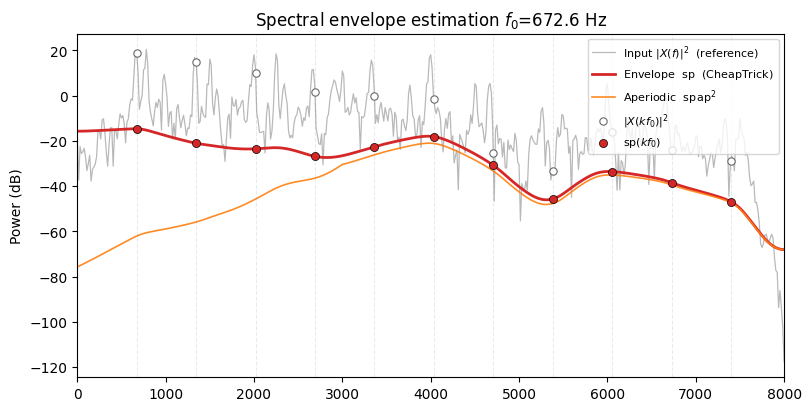

In [117]:
fig, axes = plt.subplots(1, 1, figsize=(8, 4), constrained_layout=True)

n_harm     = int((sample_rate / 2) / f0_i)
harm_freqs = np.arange(1, n_harm + 1) * f0_i
harm_env   = np.interp(harm_freqs, freqs, env_db)
harm_pow   = np.interp(harm_freqs, freqs, power_db)
harm_ap    = np.interp(harm_freqs, freqs, ap_frame)

ax = axes
ax.plot(freqs, power_db, color='gray', alpha=0.55, linewidth=0.9,
        label=r'Input $|X(f)|^2$  (reference)')
ax.plot(freqs, env_db,       color='C3', linewidth=2.0,
        label=r'Envelope  $\mathrm{sp}$  (CheapTrick)')
# ax.plot(freqs, periodic_db,  color='C2', linewidth=1.2, alpha=0.9,
#         label=r'Periodic  $\mathrm{sp}\,(1-\mathrm{ap}^2)$')
ax.plot(freqs, aperiodic_db, color='C1', linewidth=1.2, alpha=0.9,
        label=r'Aperiodic  $\mathrm{sp}\,\mathrm{ap}^2$')
for f_k in harm_freqs:
    ax.axvline(f_k, color='steelblue', alpha=0.15, linestyle='--', linewidth=0.8)
ax.scatter(harm_freqs, harm_pow, s=28, facecolor='white',
           edgecolor='dimgray', linewidth=0.8, zorder=4,
           label=r'$|X(kf_0)|^2$')
ax.scatter(harm_freqs, harm_env, s=34, marker='o', color='C3',
           edgecolor='black', linewidth=0.5, zorder=5,
           label=r'$\mathrm{sp}(kf_0)$')
ax.set_xlim(0, sample_rate / 2)
ax.set_ylabel('Power (dB)')
ax.set_title(f'Spectral envelope estimation $f_0$={f0_i:.1f} Hz')
ax.legend(loc='upper right', fontsize=8)

# ax = axes[1]
# ax.plot(freqs, ap_frame, color='C0', linewidth=1.2)
# for f_k in harm_freqs:
#     ax.axvline(f_k, color='steelblue', alpha=0.15, linestyle='--', linewidth=0.8)
# ax.scatter(harm_freqs, harm_ap, s=28, color='C0',
#            edgecolor='black', linewidth=0.4, zorder=4,
#            label=r'$\mathrm{ap}(kf_0)$')
# ax.axhline(0, color='black', linewidth=0.5, alpha=0.3)
# ax.axhline(1, color='black', linewidth=0.5, alpha=0.3)
# ax.set_xlim(0, sample_rate / 2)
# ax.set_ylim(-0.05, 1.05)
# ax.set_xlabel('Frequency (Hz)')
# ax.set_ylabel('Aperiodicity ratio')
# ax.set_title(f'Aperiodicity  ap(f)   (D4C)   —   mean = {ap_frame.mean():.3f}')
# ax.legend(loc='upper right', fontsize=8)

plt.show()

## Figure 2 — Envelope / periodic / aperiodic spectrograms

Three time–frequency images, all computed directly from WORLD's `(sp, ap)`:

- **Envelope**  $\mathrm{sp}(t, f)$
- **Periodic**  $\mathrm{sp}(t, f)\,(1 - \mathrm{ap}(t, f)^2)$
- **Aperiodic** $\mathrm{sp}(t, f)\,\mathrm{ap}(t, f)^2$

By construction envelope = periodic + aperiodic.

In [118]:
sp_T = sp.T
ap_T = ap.T
periodic_T  = sp_T * (1.0 - ap_T ** 2)
aperiodic_T = sp_T * (ap_T ** 2)

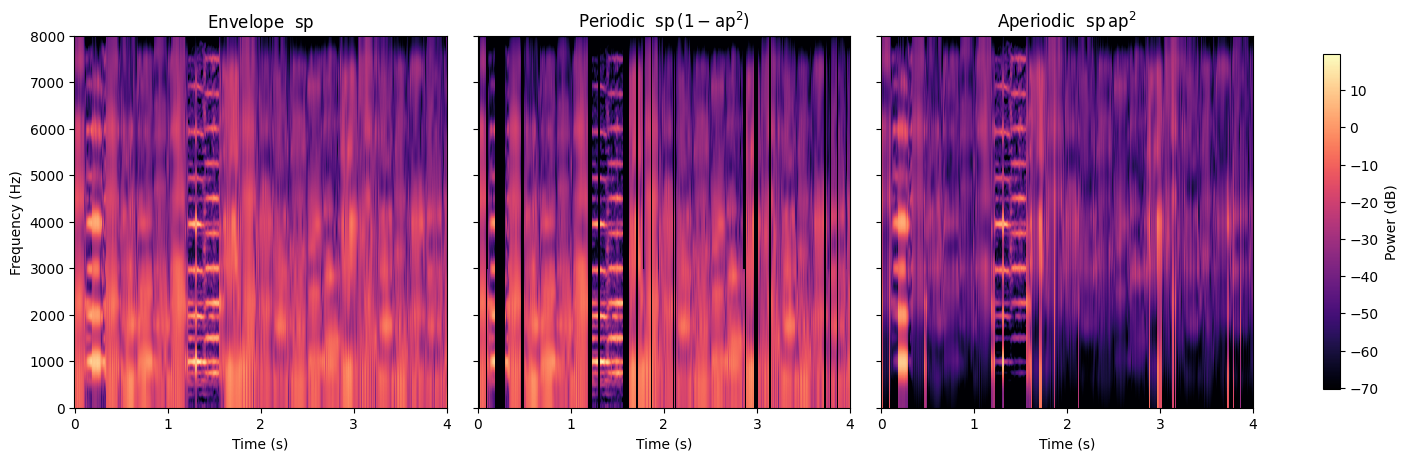

In [119]:
def to_db(x):
    return 10 * np.log10(x + eps)

sp_db  = to_db(sp_T)
per_db = to_db(periodic_T)
ap_db  = to_db(aperiodic_T)

vmax = sp_db.max()
vmin = vmax - 90

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True, constrained_layout=True)
titles = [r'Envelope  $\mathrm{sp}$',
          r'Periodic  $\mathrm{sp}\,(1-\mathrm{ap}^2)$',
          r'Aperiodic  $\mathrm{sp}\,\mathrm{ap}^2$']
mats = [sp_db, per_db, ap_db]

for ax, mat, title in zip(axes, mats, titles):
    im = ax.pcolormesh(times, freqs, mat, cmap='magma', vmin=vmin, vmax=vmax,
                       shading='auto')
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylim(0, sample_rate / 2)
axes[0].set_ylabel('Frequency (Hz)')
fig.colorbar(im, ax=axes, shrink=0.9, label='Power (dB)')
plt.show()

## Figure 3 — Full WORLD pipeline (5-panel)

Five views of the input/output pair, all derived directly from WORLD:

1. Input waveform (for reference).
2. Spectral envelope `sp(t, f)` as a time–frequency image (CheapTrick).
3. Aperiodicity ratio matrix `ap(t, f)` (D4C) with frame-aggregated aperiodic-energy ratio overlaid.
4. Periodic vs aperiodic energy contributions per frame.
5. Reconstructed waveform from `(f0, sp, ap)` via `pw.synthesize`.

In [120]:
recon = baseline.synthesize(f0, sp, ap, sample_rate)

periodic_energy  = periodic_T.sum(axis=0)
aperiodic_energy = aperiodic_T.sum(axis=0)
total_energy     = periodic_energy + aperiodic_energy + eps
mean_ap_curve    = aperiodic_energy / total_energy

t_audio = np.arange(len(audio)) / sample_rate
t_recon = np.arange(len(recon)) / sample_rate

print(f'input len: {len(audio)}   recon len: {len(recon)}')

input len: 64000   recon len: 64080


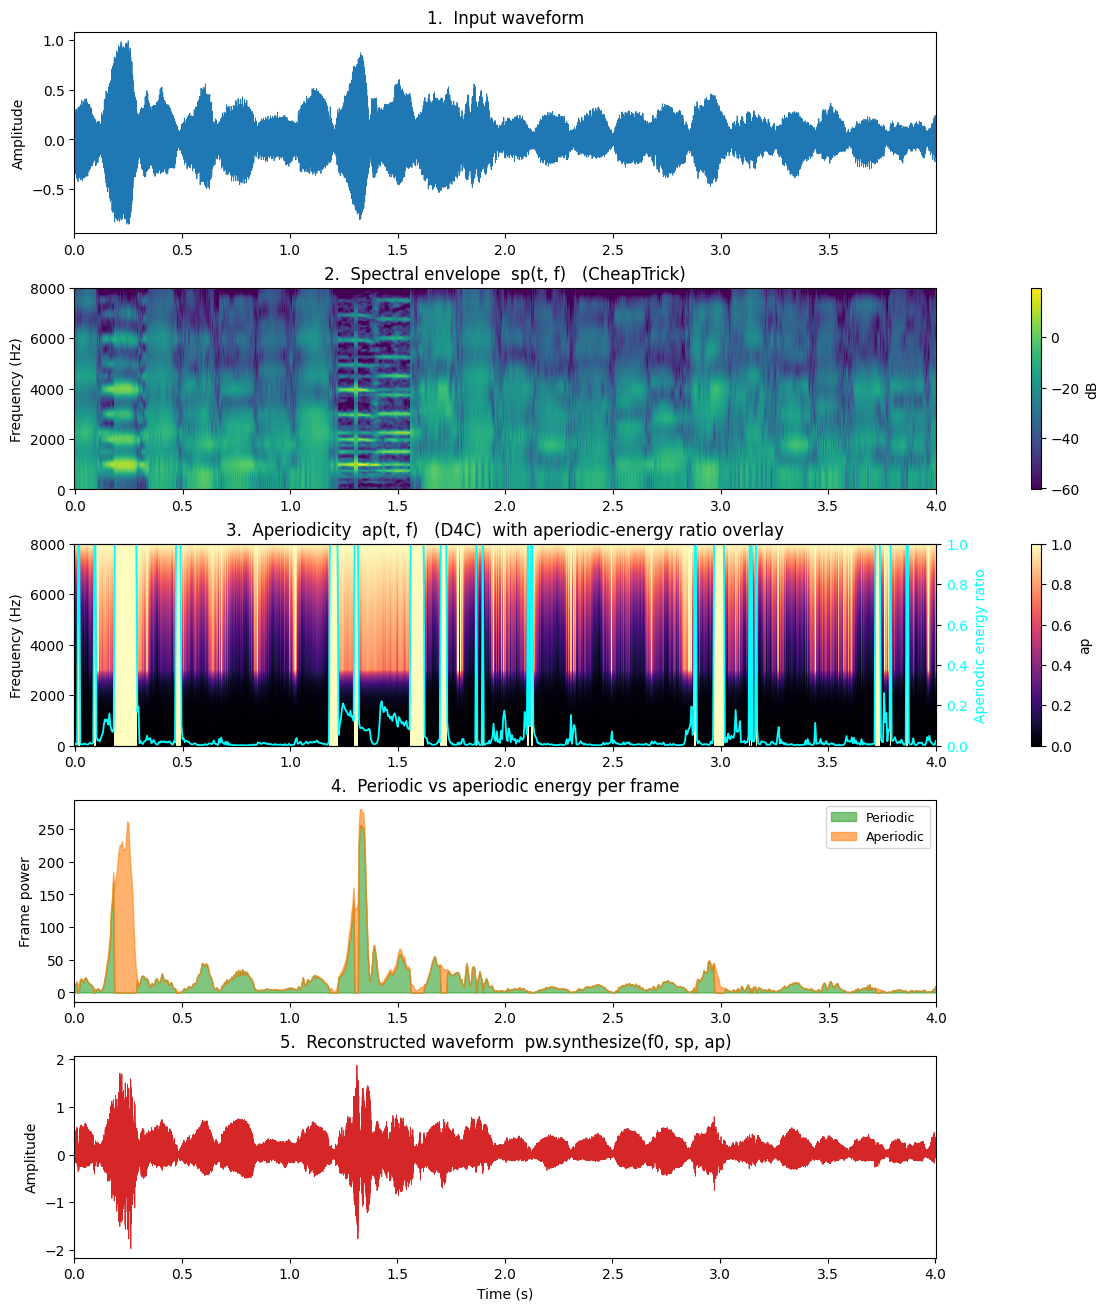

In [121]:
fig, axes = plt.subplots(5, 1, figsize=(11, 13), constrained_layout=True)

ax = axes[0]
ax.plot(t_audio, audio, color='C0', linewidth=0.6)
ax.set_ylabel('Amplitude')
ax.set_title('1.  Input waveform')
ax.set_xlim(0, t_audio[-1])

ax = axes[1]
sp_img = to_db(sp_T)
im = ax.pcolormesh(times, freqs, sp_img, cmap='viridis',
                   vmin=sp_img.max() - 80, vmax=sp_img.max(), shading='auto')
ax.set_ylabel('Frequency (Hz)')
ax.set_ylim(0, sample_rate / 2)
ax.set_title('2.  Spectral envelope  sp(t, f)   (CheapTrick)')
fig.colorbar(im, ax=ax, label='dB')

ax = axes[2]
im = ax.pcolormesh(times, freqs, ap_T, cmap='magma',
                   vmin=0, vmax=1, shading='auto')
ax.set_ylabel('Frequency (Hz)')
ax.set_ylim(0, sample_rate / 2)
ax.set_title('3.  Aperiodicity  ap(t, f)   (D4C)  with aperiodic-energy ratio overlay')
ax_r = ax.twinx()
ax_r.plot(times, mean_ap_curve, color='cyan', linewidth=1.3,
          label='aperiodic / total')
ax_r.set_ylim(0, 1)
ax_r.set_ylabel('Aperiodic energy ratio', color='cyan')
ax_r.tick_params(axis='y', labelcolor='cyan')
fig.colorbar(im, ax=ax, label='ap')

ax = axes[3]
ax.fill_between(times, 0, periodic_energy,  color='C2', alpha=0.6, label='Periodic')
ax.fill_between(times, periodic_energy, periodic_energy + aperiodic_energy,
                color='C1', alpha=0.6, label='Aperiodic')
ax.set_ylabel('Frame power')
ax.set_title('4.  Periodic vs aperiodic energy per frame')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(0, times[-1])

ax = axes[4]
ax.plot(t_recon, recon, color='C3', linewidth=0.6)
ax.set_ylabel('Amplitude')
ax.set_xlabel('Time (s)')
ax.set_title('5.  Reconstructed waveform  pw.synthesize(f0, sp, ap)')
ax.set_xlim(0, t_recon[-1])

plt.show()